# Week 5 - Additional Models

Compare Decision Tree and Random Forest regressors against the Week 4 Linear Regression baseline. This notebook also tightens the modeling dataset by handling extreme target outliers and adding more meaningful city/ZIP encodings.

## Setup

The Week 3 cleaned CSV is still the starting point. Raw CRMLS files are used only to recover `City` and `PostalCode` by `RecordId`, then the location fields are encoded using training-only target statistics.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor

DATA_DIR = Path("data")
CLEANED_PATH = DATA_DIR / "week3_cleaned.csv"
RAW_PATHS = sorted(DATA_DIR.glob("CRMLSSold*.csv"))

if not CLEANED_PATH.exists():
    raise FileNotFoundError("Missing data/week3_cleaned.csv. Run 02_preprocessing.ipynb first.")
if not RAW_PATHS:
    raise FileNotFoundError("Missing raw CRMLS CSV files in data/. They are needed for city/ZIP encodings.")

pd.options.display.float_format = "{:,.4f}".format
RANDOM_STATE = 50
TRAINING_MONTHS = 30
WEEK4_BASELINE_R2 = 0.2999484390

## Load Week 3 data and recover location fields

Week 3 exported numeric features only. Since `RecordId` was created from the raw CSV row order, this helper recreates that same ID and merges back cleaned city/ZIP values.

In [2]:
cleaned = pd.read_csv(CLEANED_PATH)


def load_location_fields(raw_paths):
    frames = []
    start_id = 0

    for path in raw_paths:
        header = pd.read_csv(path, nrows=0).columns
        usecols = [column for column in ["City", "PostalCode"] if column in header]
        frame = pd.read_csv(path, usecols=usecols, low_memory=False)

        for column in ["City", "PostalCode"]:
            if column not in frame:
                frame[column] = pd.NA

        frame["RecordId"] = np.arange(start_id, start_id + len(frame), dtype=np.int64)
        start_id += len(frame)
        frames.append(frame[["RecordId", "City", "PostalCode"]])

    locations = pd.concat(frames, ignore_index=True)
    locations["City_clean"] = (
        locations["City"].astype("string").str.strip().str.upper().replace("", pd.NA)
    )
    locations["PostalCode_clean"] = (
        locations["PostalCode"]
        .astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str[:5]
        .replace("", pd.NA)
    )
    locations["ZIP3"] = locations["PostalCode_clean"].str[:3]
    return locations[["RecordId", "City_clean", "PostalCode_clean", "ZIP3"]]


locations = load_location_fields(RAW_PATHS)
df = cleaned.merge(locations, on="RecordId", how="left", validate="one_to_one")

display(df[["RecordId", "CloseMonth", "ClosePrice", "split", "City_clean", "PostalCode_clean", "ZIP3"]].head())
display(pd.Series({"rows": len(df), "columns": len(df.columns), "raw_files": len(RAW_PATHS)}).to_frame("value"))

,RecordId,CloseMonth,ClosePrice,split,City_clean,PostalCode_clean,ZIP3
0,149621,2023-05,"695,960.0000",train,CARSON,90745,907
1,150236,2023-05,"1,700,000.0000",train,COSTA MESA,92626,926
2,150421,2023-05,"1,575,000.0000",train,SOUTH PASADENA,91030,910
3,150422,2023-05,"2,675,000.0000",train,SUNNYVALE,94087,940
4,150446,2023-05,"1,900,000.0000",train,DANA POINT,92629,926


,value
rows,393502
columns,48
raw_files,30


## Handle implausible/extreme target outliers

The raw `ClosePrice` target contains records as low as a few dollars and as high as hundreds of millions. Those values can dominate R² and make tree models chase unusual sales or data-quality problems. For this Week 5 comparison, keep sales at or above $50,000 and cap the evaluation population at the training-set 99.5th percentile. The upper threshold is learned from the available training split only. Then use a 30-month training window immediately before the May 2026 test month.

In [3]:
target_summary_before = df.groupby("split")["ClosePrice"].describe(
    percentiles=[0.01, 0.5, 0.95, 0.99, 0.995, 0.999]
)
display(target_summary_before)

LOWER_PRICE_BOUND = 50_000
train_target = df.loc[df["split"].eq("train"), "ClosePrice"]
UPPER_PRICE_BOUND = train_target.quantile(0.995)

target_keep_mask = df["ClosePrice"].between(LOWER_PRICE_BOUND, UPPER_PRICE_BOUND)
removed_summary = pd.DataFrame(
    {
        "rows_before": df.groupby("split").size(),
        "rows_removed": df.loc[~target_keep_mask].groupby("split").size(),
    }
).fillna(0).astype(int)
removed_summary["rows_after"] = removed_summary["rows_before"] - removed_summary["rows_removed"]
removed_summary["removed_percent"] = removed_summary["rows_removed"] / removed_summary["rows_before"] * 100

model_df = df.loc[target_keep_mask].copy()
model_df["CloseMonthPeriod"] = pd.PeriodIndex(model_df["CloseMonth"], freq="M")
test_month = model_df.loc[model_df["split"].eq("test"), "CloseMonthPeriod"].max()
train_start_month = test_month - TRAINING_MONTHS

time_keep_mask = (
    (model_df["split"].eq("test") & model_df["CloseMonthPeriod"].eq(test_month))
    | (
        model_df["split"].eq("train")
        & model_df["CloseMonthPeriod"].between(train_start_month, test_month - 1)
    )
)
time_window_summary = pd.Series(
    {
        "training_months_used": TRAINING_MONTHS,
        "train_start_month": str(train_start_month),
        "train_end_month": str(test_month - 1),
        "test_month": str(test_month),
        "rows_before_time_filter": len(model_df),
        "rows_after_time_filter": int(time_keep_mask.sum()),
    }
)
model_df = model_df.loc[time_keep_mask].drop(columns="CloseMonthPeriod").copy()

display(pd.Series({"lower_price_bound": LOWER_PRICE_BOUND, "upper_price_bound": UPPER_PRICE_BOUND}).to_frame("value"))
display(removed_summary)
display(time_window_summary.to_frame("value"))

,count,mean,std,min,1%,50%,95%,99%,99.5%,99.9%,max
split,,,,,,,,,,,
test,"12,024.0000","1,309,788.5996","1,678,129.9124","11,900.0000","240,000.0000","930,000.0000","3,300,000.0000","6,257,750.0000","8,413,275.0000","17,732,750.0000","97,972,500.0000"
train,"381,478.0000","1,280,080.4773","5,336,382.9661",1.1500,"236,000.0000","890,000.0000","3,101,000.0000","6,095,024.2000","8,150,000.0000","16,500,000.0000","989,500,000.0000"


,value
lower_price_bound,"50,000.0000"
upper_price_bound,"8,150,000.0000"


,rows_before,rows_removed,rows_after,removed_percent
split,,,,
test,12024,72,11952,0.5988
train,381478,2005,379473,0.5256


,value
training_months_used,30
train_start_month,2023-11
train_end_month,2026-04
test_month,2026-05
rows_before_time_filter,391425
rows_after_time_filter,337798


## Encode ZIP/city more meaningfully

Week 3 used frequency encoding for high-cardinality location columns. Here, city and ZIP get smoothed log-price target encodings. The encodings are learned only from training rows; training rows use leave-one-out encodings so a row's own target is not directly copied into its feature value.

In [4]:
train = model_df[model_df["split"].eq("train")].copy()
test = model_df[model_df["split"].eq("test")].copy()


def add_smoothed_log_target_encoding(train, test, column, smoothing=50):
    encoded_name = f"{column}_log_price_te"
    count_name = f"{column}_count_log"

    train_key = train[column].fillna("__MISSING__")
    test_key = test[column].fillna("__MISSING__")
    train_log_target = np.log1p(train["ClosePrice"])
    global_mean = train_log_target.mean()

    stats = (
        pd.DataFrame({column: train_key, "log_target": train_log_target})
        .groupby(column)["log_target"]
        .agg(["count", "sum", "mean"])
    )

    # Leave-one-out target encoding for training rows.
    train_count = train_key.map(stats["count"]).astype(float)
    train_sum = train_key.map(stats["sum"]).astype(float)
    loo_count = train_count - 1
    loo_sum = train_sum - train_log_target.to_numpy()
    train[encoded_name] = np.where(
        loo_count > 0,
        (loo_sum + smoothing * global_mean) / (loo_count + smoothing),
        global_mean,
    )

    # Full training aggregate for test rows and future/unseen data.
    smoothed_test_map = (stats["sum"] + smoothing * global_mean) / (stats["count"] + smoothing)
    train[count_name] = np.log1p(train_count)
    test[encoded_name] = test_key.map(smoothed_test_map).fillna(global_mean)
    test[count_name] = np.log1p(test_key.map(stats["count"]).fillna(0).astype(float))

    return train, test


for location_column in ["City_clean", "PostalCode_clean", "ZIP3"]:
    train, test = add_smoothed_log_target_encoding(train, test, location_column, smoothing=50)

location_feature_cols = [
    "City_clean_log_price_te", "City_clean_count_log",
    "PostalCode_clean_log_price_te", "PostalCode_clean_count_log",
    "ZIP3_log_price_te", "ZIP3_count_log",
]

display(train[location_feature_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
City_clean_log_price_te,"325,846.0000",13.7710,0.4810,12.5572,13.4584,13.7643,14.1012,15.1581
City_clean_count_log,"325,846.0000",6.9901,1.2534,0.6931,6.3404,6.9994,7.7411,9.4466
PostalCode_clean_log_price_te,"325,846.0000",13.7680,0.4809,12.5551,13.4268,13.7449,14.0841,15.1080
PostalCode_clean_count_log,"325,846.0000",6.1010,0.8433,0.6931,5.6937,6.2246,6.6201,7.7372
ZIP3_log_price_te,"325,846.0000",13.7654,0.4372,12.7881,13.3420,13.8836,14.0610,14.9221
ZIP3_count_log,"325,846.0000",9.2632,0.9091,0.6931,8.8145,9.6978,9.8181,10.2688


## Prepare model matrices

The model matrix keeps the Week 3 numeric features and adds the new location target/count encodings. Metadata and raw string location columns are excluded.

In [5]:
metadata_cols = [
    "RecordId", "CloseDate", "CloseMonth", "ClosePrice", "split",
    "City_clean", "PostalCode_clean", "ZIP3",
]
feature_cols = [column for column in train.columns if column not in metadata_cols]

X_train = train[feature_cols]
y_train = train["ClosePrice"]
X_test = test[feature_cols]
y_test = test["ClosePrice"]

assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

matrix_summary = pd.Series(
    {
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "training_months": train["CloseMonth"].nunique(),
        "train_start_month": train["CloseMonth"].min(),
        "train_end_month": train["CloseMonth"].max(),
        "feature_count": len(feature_cols),
        "test_month": test["CloseMonth"].unique()[0],
        "new_location_features": len(location_feature_cols),
    }
)
display(matrix_summary.to_frame("value"))

,value
train_rows,325846
test_rows,11952
training_months,30
train_start_month,2023-11
train_end_month,2026-04
feature_count,46
test_month,2026-05
new_location_features,6


## Train and compare models

The Linear Regression row is a fair Week 5 baseline because it uses the same 30-month training window, outlier-handled target range, and enriched feature matrix as the tree models. The original Week 4 baseline R² is kept as a reference point, but it was evaluated on the full, unfiltered test set.

In [6]:
def median_absolute_percentage_error(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true))


models = {
    "Linear Regression baseline": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=22,
        min_samples_leaf=25,
        random_state=RANDOM_STATE,
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=60,
        max_depth=22,
        min_samples_leaf=10,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

results = []
predictions = {}

for model_name, model in models.items():
    start = perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = perf_counter() - start

    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred

    results.append(
        {
            "model": model_name,
            "test_r2": r2_score(y_test, y_pred),
            "mae": mean_absolute_error(y_test, y_pred),
            "rmse": root_mean_squared_error(y_test, y_pred),
            "mdape": median_absolute_percentage_error(y_test, y_pred),
            "negative_predictions": int((y_pred < 0).sum()),
            "fit_seconds": fit_seconds,
        }
    )

results = pd.DataFrame(results).sort_values("test_r2", ascending=False).reset_index(drop=True)
results["r2_gain_vs_week5_linear"] = results["test_r2"] - results.loc[
    results["model"].eq("Linear Regression baseline"), "test_r2"
].iloc[0]
results["r2_gain_vs_original_week4"] = results["test_r2"] - WEEK4_BASELINE_R2

display(results.style.format({
    "test_r2": "{:.4f}",
    "mae": "${:,.0f}",
    "rmse": "${:,.0f}",
    "mdape": "{:.2%}",
    "fit_seconds": "{:.1f}",
    "r2_gain_vs_week5_linear": "{:+.4f}",
    "r2_gain_vs_original_week4": "{:+.4f}",
}))

,model,test_r2,mae,rmse,mdape,negative_predictions,fit_seconds,r2_gain_vs_week5_linear,r2_gain_vs_original_week4
0,Random Forest Regressor,0.8377,"$199,699","$392,768",10.58%,0,5.3,+0.1022,+0.5377
1,Linear Regression baseline,0.7355,"$310,575","$501,385",20.61%,421,0.4,+0.0000,+0.4355
2,Decision Tree Regressor,0.7353,"$267,366","$501,570",14.79%,0,5.9,-0.0002,+0.4353


## Model diagnostics

The Random Forest is expected to be the strongest of these first additional models because it averages many trees, reducing the instability of one deep tree.

,feature,importance
42,PostalCode_clean_log_price_te,0.2370
40,City_clean_log_price_te,0.1968
1,LivingArea_scaled,0.1253
44,ZIP3_log_price_te,0.1150
5,Bathrooms_scaled,0.0994
39,Levels_frequency,0.0237
19,Longitude_scaled,0.0213
7,LotSizeSquareFeet_scaled,0.0196
45,ZIP3_count_log,0.0185
3,Bedrooms_scaled,0.0170


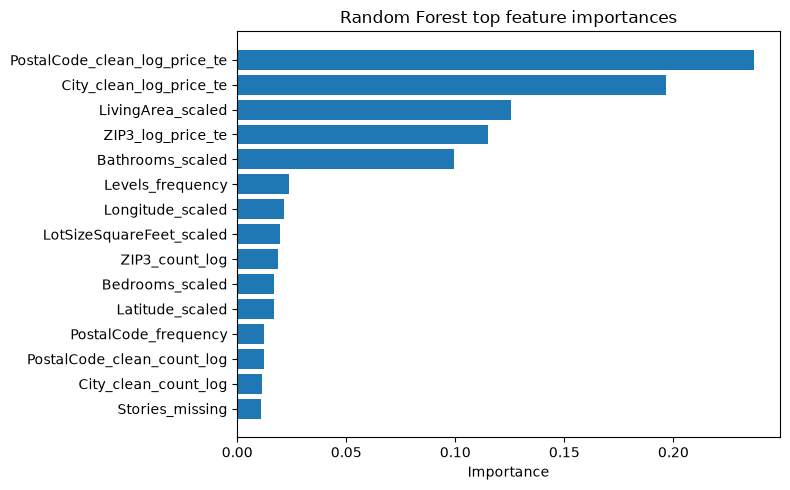

In [7]:
forest_model = models["Random Forest Regressor"]
forest_importance = (
    pd.DataFrame({"feature": feature_cols, "importance": forest_model.feature_importances_})
    .sort_values("importance", ascending=False)
    .head(15)
)

display(forest_importance)

plt.figure(figsize=(8, 5))
plt.barh(forest_importance["feature"][::-1], forest_importance["importance"][::-1])
plt.title("Random Forest top feature importances")
plt.xlabel("Importance")
plt.tight_layout()

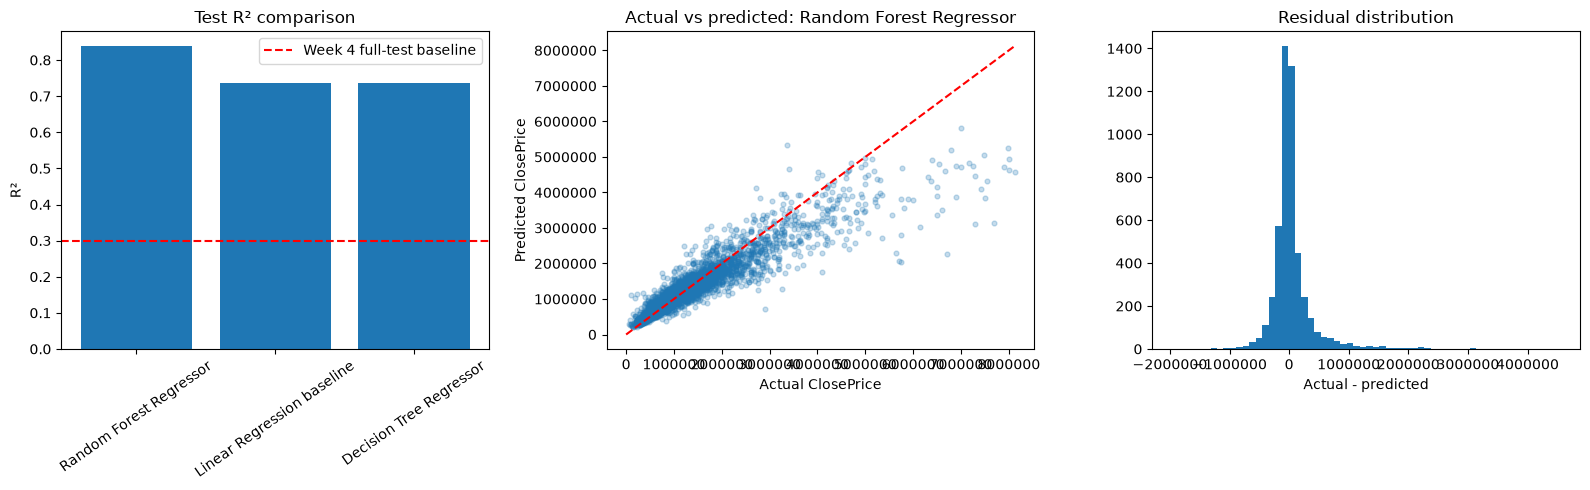

In [8]:
best_model_name = results.iloc[0]["model"]
best_predictions = predictions[best_model_name]

plot_data = pd.DataFrame(
    {
        "actual": y_test.to_numpy(),
        "predicted": best_predictions,
        "residual": y_test.to_numpy() - best_predictions,
    }
).sample(n=min(5_000, len(y_test)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(results["model"], results["test_r2"])
axes[0].axhline(WEEK4_BASELINE_R2, color="red", linestyle="--", label="Week 4 full-test baseline")
axes[0].set_title("Test R² comparison")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend()

axes[1].scatter(plot_data["actual"], plot_data["predicted"], alpha=0.25, s=12)
price_max = max(plot_data["actual"].max(), plot_data["predicted"].max())
axes[1].plot([0, price_max], [0, price_max], color="red", linestyle="--")
axes[1].set_title(f"Actual vs predicted: {best_model_name}")
axes[1].set_xlabel("Actual ClosePrice")
axes[1].set_ylabel("Predicted ClosePrice")
axes[1].ticklabel_format(style="plain", axis="both")

axes[2].hist(plot_data["residual"], bins=60)
axes[2].set_title("Residual distribution")
axes[2].set_xlabel("Actual - predicted")
axes[2].ticklabel_format(style="plain", axis="x")

plt.tight_layout()

## Model behavior notes

- **Linear Regression baseline:** fast and useful as a benchmark, but it assumes mostly linear feature effects. It improved after target outlier handling and location encodings, yet still underfits nonlinear housing patterns.
- **Decision Tree Regressor:** captures nonlinear splits and interactions, and it lowered typical dollar/percentage errors versus linear regression in this run. Its weakness showed up in R²: one tree made some larger misses, so it slightly trailed the linear baseline on squared-error performance.
- **Random Forest Regressor:** performed best in this comparison because averaging many trees reduces single-tree overfitting. The tradeoff is slower training and less direct interpretability. It can still smooth away rare luxury-home behavior, especially after the extreme target filter.

The Week 5 comparison uses a filtered target range, so the refit Linear Regression row is the fairest baseline for the tree models. The original Week 4 R² is still shown as historical context, but it was calculated on the unfiltered May 2026 test set.

## Week 5 outcome

Random Forest outperforms the Week 5 Linear Regression baseline on the target-filtered May 2026 test set. The single Decision Tree improves typical error metrics but trails Linear Regression on R², which is useful evidence that one tree is too brittle for this dataset. Random Forest is the strongest model in this round because it handles nonlinear relationships while reducing the overfitting risk of a single tree.